In [1]:
# get prop
import numpy as np
import requests
import matplotlib.pyplot as plt
import pandas as p
from IPython.display import display, HTML

#get data
from astroquery.mast import Observations
from astroquery.mast import Catalogs
from astropy.io import fits
from astropy import table
import matplotlib.pyplot as plt
import numpy as np
from copy import deepcopy
from corner import corner
from astropy.table import Table

%matplotlib inline

planeturl = "https://exo.mast.stsci.edu/api/v0.1/exoplanets/"
dvurl = "https://exo.mast.stsci.edu/api/v0.1/dvdata/tess/"
url = planeturl + "/identifiers/"
header={}

# mcmc
import pandas as pd
import seaborn as sb

from pathlib import Path
from uncertainties import ufloat
from scipy.stats import norm

from pytransit.lpf.tesslpf import TESSLPF, fold, downsample_time
from pytransit.orbits import epoch
from scipy.optimize import curve_fit

In [2]:
mcmc_repeats = 4

In [3]:
class fitransit:
    
    
    def __init__(self, planet_name: str, datadir = None, tic: int = None, zero_epoch: float = None, period: float = None, prop = None):
        
        if datadir == None:
            datadir = './data/' + planet_name.replace(' ','')
        myparams = {"name":planet_name}
        url = planeturl + "/identifiers/"
        r = requests.get(url = url, params = myparams, headers = header)
        # print(r.headers.get('content-type'))
        planet_names = r.json()
        self.ticid = planet_names['tessID']
        self.tce = planet_names['tessTCE']
        url = planeturl + planet_name + "/properties/"
        r = requests.get(url = url, headers = header)
        self.prop = r.json()
        self.planet_name = planet_name
        self.data_dir = datadir
        self.lpf = None
        self.period = self.prop[0]['orbital_period']
        self.transit_time = self.prop[0]['transit_time']
        self.tc = ufloat(self.transit_time,max(self.prop[0]['transit_time_lower'],self.prop[0]['transit_time_upper']))

    def get_parameters(self):
        
        return self.prop
        
    def print_parameters(self):

        planet_prop = self.prop
        print(self.planet_name + " Properties")
        print("Stellar Mass \t\t%f \t\t%s" % \
              (planet_prop[0]['Ms'], planet_prop[0]['Ms_unit'] ) )
        print("Planet Mass \t\t%f \t\t%s" % \
              (planet_prop[0]['Mp'], planet_prop[0]['Mp_unit'] ) )
        print("Planet Orbital Period \t%f \t\t%s" % \
              (planet_prop[0]['orbital_period'], \
               planet_prop[0]['orbital_period_unit'] ) )
        print("Transit Time \t\t%f \t\t%s" % \
              (planet_prop[0]['transit_time'] + 0.5, \
               planet_prop[0]['transit_time_unit'] ) )
        print("Planet Mass Reference: %s" % \
              (planet_prop[0]['Mp_ref']))
        
    def download_data(self):
        
        observations = Observations.query_object(self.planet_name,radius = "0 deg")
        obs_wanted = (observations['dataproduct_type'] \
                      == 'timeseries') & (observations['obs_collection'] == 'TESS')
        print( observations[obs_wanted]['obs_collection', 'project','obs_id'] )
        data_products = Observations.get_product_list(observations[obs_wanted])
        products_wanted = Observations.filter_products(data_products, 
                                            productSubGroupDescription=["DVT","LC"])

        print(products_wanted["productFilename"])
        manifest = Observations.download_products(products_wanted,download_dir=self.data_dir)
        print('\nfinished!')
        
    def set_lpf(self,data,modified_transit_time=None,modified_period=None):
        npop         = 30
        mcmc_repeats = 4
        datadir = data

        planet_prop = self.prop
        transit_time = planet_prop[0]['transit_time'] + 2.4e6 + 0.5
        transit_time_err = max(planet_prop[0]['transit_time_lower'],planet_prop[0]['transit_time_upper'])
        orbital_period = planet_prop[0]['orbital_period']
        orbital_period_err = max(planet_prop[0]['orbital_period_lower'],planet_prop[0]['orbital_period_upper'])

        if modified_transit_time == None:
            zero_epoch = ufloat(transit_time,transit_time_err)
        else:
            zero_epoch = ufloat(modified_transit_time,transit_time_err)
        if modified_period == None:
            period = ufloat(orbital_period,orbital_period_err)
        else:
            period = ufloat(modified_period,orbital_period_err)
            
        self.tc = zero_epoch
    
    
        self.lpf = TESSLPF(self.planet_name,datadir,tic=self.ticid,zero_epoch=zero_epoch.n,period=period.n,use_pdc=True,nsamples=2, bldur=0.25)
        
    
        ep = epoch(self.lpf.times[0].mean(), self.lpf.zero_epoch, self.lpf.period)
        tc = zero_epoch + ep*period

        self.lpf.set_prior('tc', 'NP', tc.n,     0.0005)          # Wide normal prior on the transit center
        self.lpf.set_prior('p',  'NP', period.n, period.s)  # Wide normal prior on the orbital period
        self.lpf.set_prior('rho', 'UP', 0, 1)               # Uniform prior on the stellar density
        self.lpf.set_prior('k2', 'UP', 0.0, 0.2**2)             # Uniform prior on the area ratio
        self.lpf.set_prior('gp_ln_in', 'UP', -2, 1)             # Uniform prior on the GP input scale
        self.lpf.optimize_global(200, npop=npop)
        
    def mcmc(self):
        self.lpf.sample_mcmc(2500, thin=25, repeats=mcmc_repeats)
    
    def corner_plot(self,nrows=5,ncols=5,figsize=(6.5,6.5)):
        
        fig,ax = plt.subplots(nrows,ncols,figsize)
        df = self.lpf.posterior_samples()
        corner(df['tc p rho b k'.split()],
        labels='\n\n\nZero epoch, \n\n\nPeriod, \n\n\nStellar density, \n\n\nimpact parameter, \n\n\nradius ratio'.split(', '),fig=fig,show_titles=True)
        plt.subplots_adjust(wspace=0.2,hspace=0.2)
        return fig

# WASP-71 b

In [4]:
wasp71b = fitransit("WASP-71 b")

In [5]:
wasp71b.print_parameters()
# wasp71b.download_data()

WASP-71 b Properties
Stellar Mass 		1.572000 		M_sun
Planet Mass 		2.242000 		M_Jupiter
Planet Orbital Period 	2.903675 		d
Transit Time 		55738.849770 		MJD
Planet Mass Reference: Smith 2013


Global optimisation:   0%|          | 0/200 [00:00<?, ?it/s]

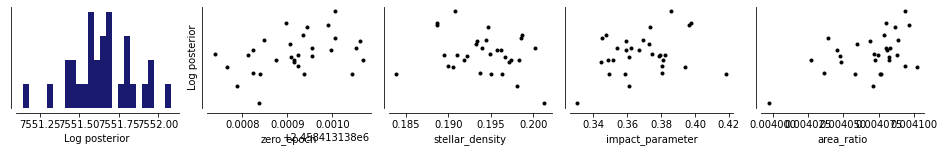

In [6]:
wasp71b.set_lpf('./data/WASP-71b/mastDownload/TESS/tess2018292075959-s0004-0000000422655579-0124-s/')

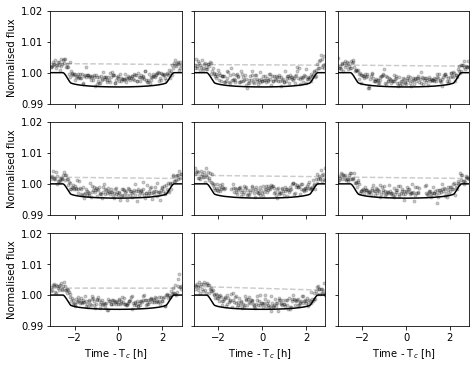

In [7]:
fig = wasp71b.lpf.plot_individual_transits(figsize=(6.5,5),ncols=3,ylim=(0.99,1.02))
fig.savefig('./image/wasp71b_individual_tansits.pdf')

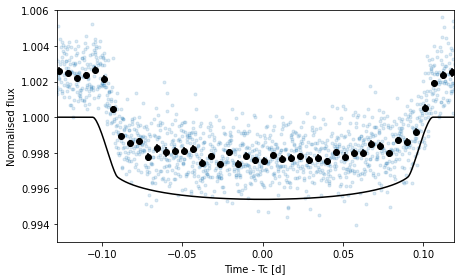

In [17]:
fig = wasp71b.lpf.plot_folded_transit(figsize=(6.5,4),ylim=(0.993, 1.006))
fig.savefig('./image/wasp71b_folded_tansit.pdf')

In [16]:
wasp71b.mcmc()

MCMC sampling:   0%|          | 0/4 [00:00<?, ?it/s]

Run 1/4:   0%|          | 0/2500 [00:00<?, ?it/s]

Run 2/4:   0%|          | 0/2500 [00:00<?, ?it/s]

Run 3/4:   0%|          | 0/2500 [00:00<?, ?it/s]

Run 4/4:   0%|          | 0/2500 [00:00<?, ?it/s]

In [10]:
wasp71b.lpf.print_parameters(columns=1)

  0 |G| tc             N(μ = 2458413.1341687003, σ = 0.0005)    [    -inf ..      inf]
  1 |G| p              N(μ = 2.9036747000000003, σ = 6.8e-06)   [    0.00 ..      inf]
  2 |G| rho            U(a = 0, b = 1)                          [    0.00 ..      inf]
  3 |G| b              U(a = 0.0, b = 1.0)                      [    0.00 ..     1.00]
  4 |P| k2             U(a = 0.0, b = 0.04000000000000001)      [    0.00 ..      inf]
  5 |P| q1_TESS        U(a = 0, b = 1)                          [    0.00 ..     1.00]
  6 |P| q2_TESS        U(a = 0, b = 1)                          [    0.00 ..     1.00]
  7 |L| gp_ln_out      N(μ = -6.0, σ = 1.5)                     [    -inf ..      inf]
  8 |L| gp_ln_in       U(a = -2, b = 1)                         [    -inf ..      inf]
  9 |L| gp_log10_wn    N(μ = -2.941150290750548, σ = 0.025)     [    -inf ..      inf]


###### plt.plot(lpf.times[0])

Text(0, 0.5, 'Residual')

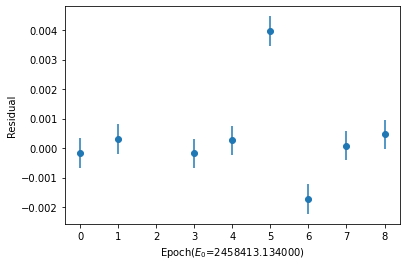

In [11]:
lpf = wasp71b.lpf

ep = epoch(lpf.times[0].mean(), lpf.zero_epoch, lpf.period)
mean_v = np.vectorize(np.mean)

tcs = mean_v(lpf.times)
tcs_err = np.ones((1,len(tcs)))[0] * 5e-4

epoch_v = np.vectorize(epoch)
epochs = epoch_v(tcs,lpf.zero_epoch, lpf.period)

# tcs = np.insert(tcs,0,wasp44b.lpf.zero_epoch)
# epochs = np.insert(epochs,0,0)
re = tcs - epochs * lpf.period - lpf.zero_epoch
e = epochs - epochs[0]

y = lambda x,a,b: a*np.sin(x) + b
rlt = curve_fit(y,e,re)



x = np.linspace(0,e[-1],100)
# tcs - epochs * lpf.period - tcs[0]
# plt.plot(x,rlt[0][0]*np.sin(x)+rlt[0][1],c='k')
plt.scatter(e,re)
plt.errorbar(e,re,yerr=tcs_err,linestyle=' ')
plt.xlabel(r"Epoch($E_0$={:.6f})".format(tcs[0]))
plt.ylabel("Residual")

Text(0, 0.5, 'Residual')

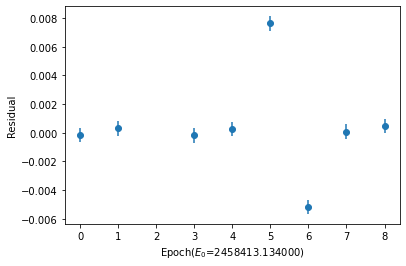

In [14]:
lpf = wasp71b.lpf

ep = epoch(lpf.times[0].mean(), lpf.zero_epoch, lpf.period)
median_v = np.vectorize(np.median)

tcs = median_v(lpf.times)
tcs_err = np.ones((1,len(tcs)))[0] * 5e-4

epoch_v = np.vectorize(epoch)
epochs = epoch_v(tcs,lpf.zero_epoch, lpf.period)

re = tcs - epochs * lpf.period - lpf.zero_epoch
e = epochs - epochs[0]

# y = lambda x,a,b: a*np.sin(x) + b
# rlt = curve_fit(y,e,re)



x = np.linspace(0,e[-1],100)
# tcs - epochs * lpf.period - tcs[0]
# plt.plot(x,rlt[0][0]*np.sin(x)+rlt[0][1],c='k')
plt.scatter(e,re)
plt.errorbar(e,re,yerr=tcs_err,linestyle=' ')
plt.xlabel(r"Epoch($E_0$={:.6f})".format(tcs[0]))
plt.ylabel("Residual")